### Capstone Project - Customer Churn (AI)
#### by Gaurav Singh (grv08singh@gmail.com)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Flatten, Dropout


import warnings as wr
wr.filterwarnings('ignore')

#### Problem Statement:
You are the Data Scientist at a telecom company “Leo” whose customers are churning out to its competitors. You have to analyse the data of your company and find insights and stop your customers from churning out to other telecom companies.

In [2]:
df = pd.read_csv('customer_churn.csv')
df.shape

(7043, 21)

#### Tasks to be done:
##### A) Data Manipulation:
a. Find the total number of male customers

In [3]:
df[df['gender'] == 'Male'].shape[0]

3555

b. Find the total number of customers whose Internet Service is ‘DSL’

In [4]:
df[df['InternetService'] == 'DSL'].shape[0]

2421

c. Extract all the Female senior citizens whose Payment Method is Mailed check & store the result in ‘new_customer’

In [5]:
new_customer = df[(df['gender'] == 'Female') & (df['SeniorCitizen'] == 1) & (df['PaymentMethod'] == 'Mailed check')]

d. Extract all those customers whose tenure is less than 10 months or their Total charges is less than 500$ & store the result in ‘new_customer’

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

new_customer = df[(df['tenure'] < 10) | (df['TotalCharges'] < 500)]

##### B) Data Visualization:
a. Build a pie-chart to show the distribution of customers would be churning out

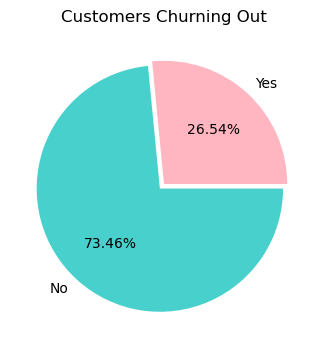

In [7]:
churn_data = df['Churn'].value_counts()

plt.figure(figsize=(4,4))
plt.pie(x=churn_data, 
        labels=churn_data.index, 
        explode=[0.05,0], 
        colors=['mediumturquoise','lightpink'], 
        autopct='%0.2f%%', 
        counterclock=False
)
plt.title("Customers Churning Out")
plt.show()

b. Build a bar-plot to show the distribution of ‘Internet Service’

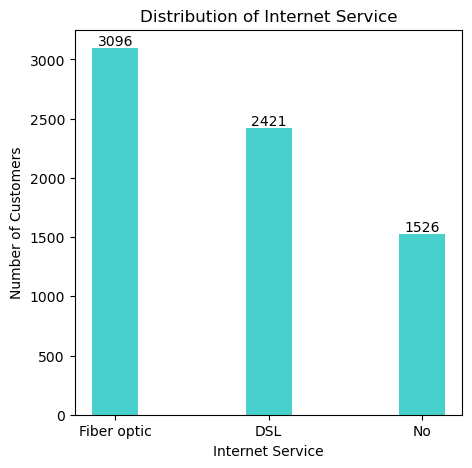

In [8]:
internet_data = df['InternetService'].value_counts()

fig,ax = plt.subplots(figsize=(5,5))
container = ax.bar(x=internet_data.index, height=internet_data, width=0.3, color='mediumturquoise')
ax.bar_label(container=container)
ax.set_xlabel('Internet Service')
ax.set_ylabel('Number of Customers')
ax.set_title('Distribution of Internet Service')
plt.show()

##### C) Model Building:
##### a. Build a sequential model using Keras, to find out if the customer would churn or not, using `tenure` as the feature and `Churn` as the dependent/target column:

* i. The visible/input layer should have 12 nodes with ‘Relu’ as activation function.
* ii. This model would have 1 hidden layer with 8 nodes and ‘Relu’ as activation function.

In [9]:
df_X = df.drop(columns=['Churn'])
y = df['Churn']

In [10]:
#Train Test Split
X = df_X[['tenure']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [11]:
#Label Encode y data
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [12]:
#scale X data
sc = StandardScaler()
X_train_scaled = sc.fit_transform(pd.DataFrame(X_train))
X_test_scaled = sc.transform(pd.DataFrame(X_test))

In [13]:
#build model
m1 = Sequential()
m1.add(Dense(12, activation='relu', input_shape=X_train_scaled.shape[1:]))
m1.add(Dense(8, activation='relu'))
m1.add(Dense(1, activation='sigmoid'))

m1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 12)                  │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

iii. Use ‘Adam’ as the optimization algorithm.

In [14]:
m1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

iv. Fit the model on the train set, with number of epochs to be 150

In [15]:
epochs = 150
h1 = m1.fit(X_train_scaled, y_train_enc, epochs=epochs, batch_size=32)

Epoch 1/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6606 - loss: 0.6205 
Epoch 2/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7316 - loss: 0.5206 
Epoch 3/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7416 - loss: 0.5154 
Epoch 4/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7528 - loss: 0.5141 
Epoch 5/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7458 - loss: 0.5138  
Epoch 6/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7457 - loss: 0.5135 
Epoch 7/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7490 - loss: 0.5135  
Epoch 8/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7446 - loss: 0.5137  
Epoch 9/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7497 - loss: 0.5132 
Epoch 10/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7458 - loss: 0.5128 
Epoch 11/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7504 - loss: 0.5133  
Epoch 12/150
177/177 ━━━━━

v. Predict the values on the test set and build a confusion matrix

In [16]:
y_pred_m1 = m1.predict(x=X_test_scaled).flatten()
y_pred_m1 = [1 if i>0.5 else 0 for i in y_pred_m1]

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [17]:
confusion_matrix(y_test_enc, y_pred_m1)

array([[965,  96],
       [234, 114]])

vi. Plot the ‘Accuracy vs Epochs’ graph

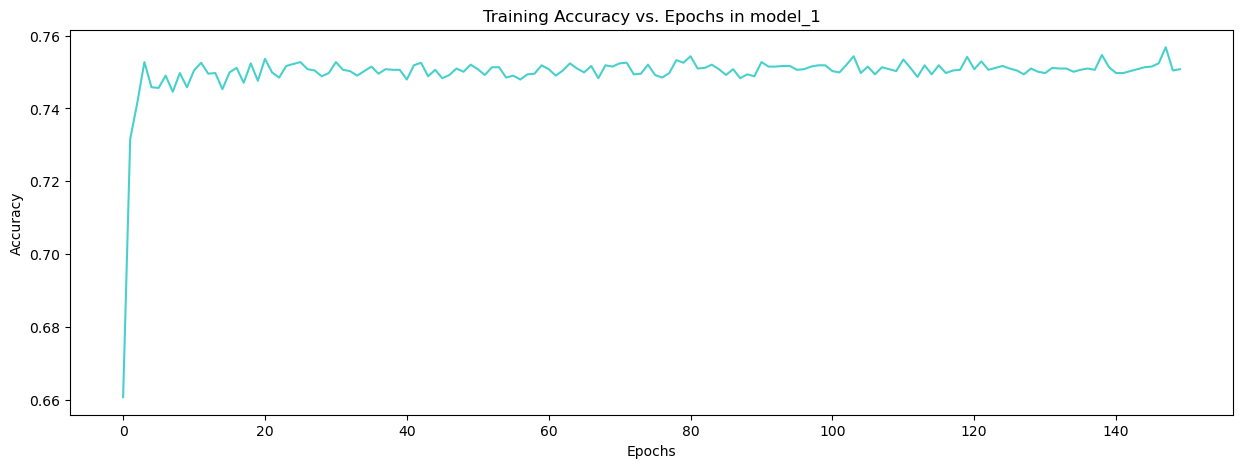

In [18]:
acc_m1 = h1.history['accuracy']
epoch_range = np.arange(epochs)

fig,ax = plt.subplots(figsize=(15,5))
ax.plot(epoch_range, acc_m1, color='mediumturquoise')
ax.axis(True)
ax.set_xlabel('Epochs')
ax.set_ylabel('Accuracy')
ax.set_title('Training Accuracy vs. Epochs in model_1')

plt.show()

##### b. Build the 2nd model using same target and feature variables:
i. Add a drop-out layer after the input layer with drop-out value of 0.3

ii. Add a drop-out layer after the hidden layer with drop-out value of 0.2

In [19]:
#build model
m2 = Sequential()
m2.add(Dense(12, activation='relu', input_shape=X_train_scaled.shape[1:]))
m2.add(Dropout(0.3))
m2.add(Dense(8, activation='relu'))
m2.add(Dropout(0.2))
m2.add(Dense(1, activation='sigmoid'))

m2.summary()

m2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 12)                  │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
h2 = m2.fit(X_train_scaled, y_train_enc, epochs=epochs, batch_size=32)

Epoch 1/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6796 - loss: 0.6178 
Epoch 2/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7274 - loss: 0.5430    
Epoch 3/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7295 - loss: 0.5334    
Epoch 4/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7315 - loss: 0.5304 
Epoch 5/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7322 - loss: 0.5340 
Epoch 6/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7378 - loss: 0.5317 
Epoch 7/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7350 - loss: 0.5296    
Epoch 8/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7426 - loss: 0.5285 
Epoch 9/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7352 - loss: 0.5273  
Epoch 10/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7387 - loss: 0.5248  
Epoch 11/150
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7414 - loss: 0.5251 
Epoch 12/150
177/17

iii. Predict the values on the test set and build a confusion matrix

In [21]:
y_pred_m2 = m2.predict(x=X_test_scaled)
y_pred_m2 = [1 if i>=0.5 else 0 for i in y_pred_m2]
confusion_matrix(y_test_enc, y_pred_m2)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([[965,  96],
       [234, 114]])

iv. Plot the ‘Accuracy vs Epochs’ graph

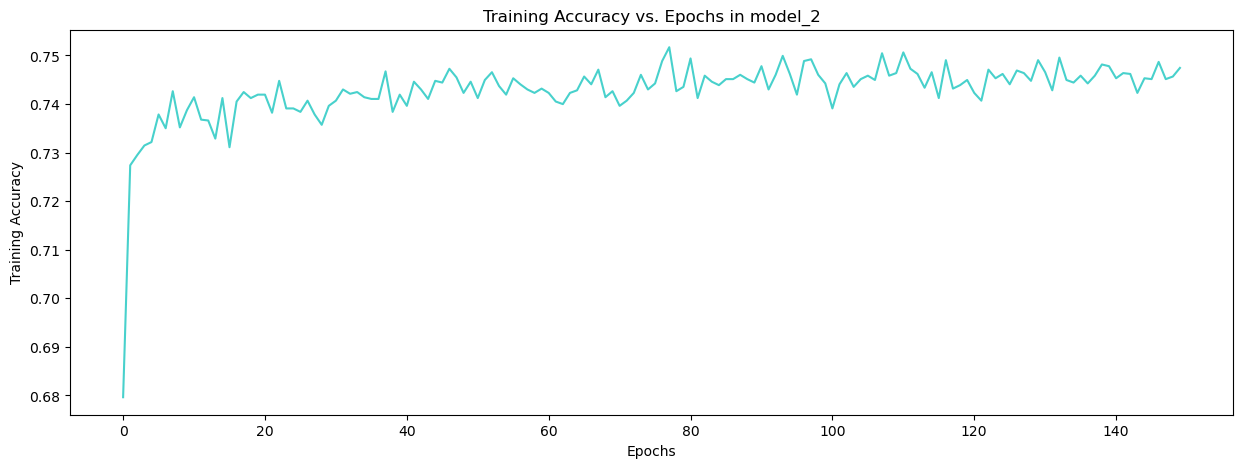

In [22]:
acc_m2 = h2.history['accuracy']

fig,ax = plt.subplots(figsize=(15,5))

ax.plot(epoch_range, acc_m2, color='mediumturquoise')
ax.axis(True)
ax.set_xlabel('Epochs')
ax.set_ylabel('Training Accuracy')
ax.set_title('Training Accuracy vs. Epochs in model_2')

plt.show()

##### c. Build the 3rd model using ‘Tenure’, ’Monthly Charges’ & ‘Total Charges’ as the features and ‘Churn’ as the dependent/target column:

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#since, there are some null values in TotalCharges, these null values need to be removed from the dataset.

In [24]:
df.shape

(7043, 21)

In [25]:
df1 = df.dropna()
df1.shape

(7032, 21)

In [26]:
#Train Test Split
X = df1[['tenure','MonthlyCharges','TotalCharges']]
y = df1['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

In [27]:
#Label Encode y data
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [28]:
#scale X data
sc = StandardScaler()
X_train_scaled = sc.fit_transform(pd.DataFrame(X_train))
X_test_scaled = sc.transform(pd.DataFrame(X_test))

i. The visible/input layer should have 12 nodes with ‘Relu’ as activation function.

ii. This model would have 1 hidden layer with 8 nodes and ‘Relu’ as activation function

In [29]:
#build model
m3 = Sequential()
m3.add(Dense(12, activation='relu', input_shape=X_train_scaled.shape[1:]))
m3.add(Dense(8, activation='relu'))
m3.add(Dense(1, activation='sigmoid'))

m3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 12)                  │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

iii. Use ‘Adam’ as the optimization algorithm

In [30]:
m3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

iv. Fit the model on the train set, with number of epochs to be 150

In [31]:
h3 = m3.fit(X_train_scaled, y_train_enc, epochs=150)

Epoch 1/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7440 - loss: 0.5301 
Epoch 2/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7724 - loss: 0.4761    
Epoch 3/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7767 - loss: 0.4643 
Epoch 4/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7828 - loss: 0.4592  
Epoch 5/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7867 - loss: 0.4560 
Epoch 6/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7881 - loss: 0.4537 
Epoch 7/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7909 - loss: 0.4514  
Epoch 8/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7922 - loss: 0.4506 
Epoch 9/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7908 - loss: 0.4500 
Epoch 10/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7924 - loss: 0.4498 
Epoch 11/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7922 - loss: 0.4494  
Epoch 12/150
176/176 ━━━

v. Predict the values on the test set and build a confusion matrix

In [32]:
y_pred_m3 = m3.predict(x=X_test_scaled)
y_pred_m3 = [1 if i>=0.5 else 0 for i in y_pred_m3]
confusion_matrix(y_test_enc, y_pred_m3)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


array([[954,  78],
       [227, 148]])

vi. Plot the ‘Accuracy vs Epochs’ graph

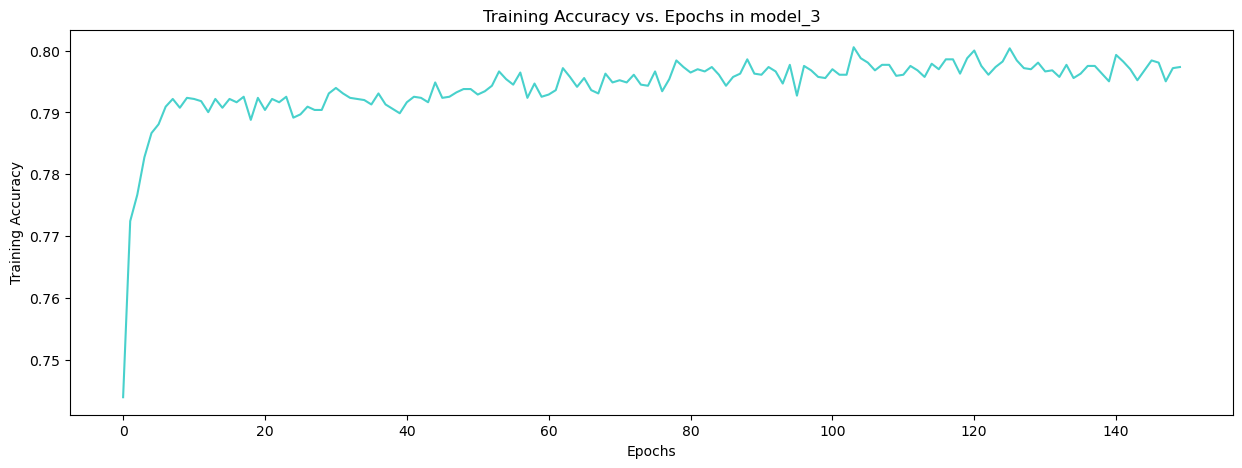

In [33]:
acc_m3 = h3.history['accuracy']

fig,ax = plt.subplots(figsize=(15,5))

ax.plot(epoch_range, acc_m3, color='mediumturquoise')
ax.axis(True)
ax.set_xlabel('Epochs')
ax.set_ylabel('Training Accuracy')
ax.set_title('Training Accuracy vs. Epochs in model_3')

plt.show()